# Blind Maze Search - Multiple Goals Analysis

This notebook analyzes BFS and DFS fringe size growth across multiple goal states.

In [ ]:
# CAP 6635  Artificial Intelligence, 2024 Spring
# Jan. 22 2024, X. Zhu
# code credit: Adapted from following github project with revision
# https://gist.github.com/Nicholas-Swift/003e1932ef2804bebef2710527008f44

import numpy as np
import matplotlib.pyplot as plt

class Node():
    """A search node class for Maze Pathfinding"""

    def __init__(self, parent=None, position=None):
        self.parent = parent
        self.position = position
        self.c = 0  # cost from source to current node

    def __eq__(self, other):
        return self.position == other.position

    def __hash__(self):
        return hash(self.position)


def search_path(maze, start, end, method='DFS'):
    """Returns a list of tuples as a path from the given start to the given end in the given maze"""

    # Create start and end node
    start_node = Node(None, start)
    start_node.c = 0
    end_node = Node(None, end)
    end_node.c = 0

    # Initialize both open and closed list
    open_list = []
    closed_list = set()

    # Add the start node
    open_list.append(start_node)

    # Loop until you find the end
    expanded_nodes=0
    queue_size=0
    while len(open_list) > 0:

        # Get the current node
        current_node = open_list[0]
        current_index = 0

        # Pop current off open list, add to closed list
        # depending on how the nodes are added to the queue, this will implement either FIFO (BFS), or LIFO (DFS)
        open_list.pop(current_index)
        closed_list.add(current_node)

        # Found the goal
        if current_node == end_node:
            path = []
            current = current_node
            while current is not None:
                path.append(current.position)
                current = current.parent
            return(expanded_nodes,queue_size,path[::-1])

        # Generate children
        expanded_nodes=expanded_nodes+1
        if(len(open_list)>queue_size):
            queue_size=len(open_list)
        children = []
        for new_position in [(0, -1), (0, 1), (-1, 0), (1, 0), (-1, -1), (-1, 1), (1, -1), (1, 1)]:

            # Get node position
            node_position = (current_node.position[0] + new_position[0], current_node.position[1] + new_position[1])

            # Make sure within range
            if node_position[0] > (len(maze) - 1) or node_position[0] < 0 or node_position[1] > (len(maze[len(maze)-1]) -1) or node_position[1] < 0:
                continue

 
            if maze[node_position[0]][node_position[1]] != 0:
                continue

            # Create new node
            new_node = Node(current_node, node_position)

            # Append
            children.append(new_node)

        # Loop through children
        for child in children:

            # Child is on the closed list
            if child in closed_list:
                continue

     
            child.c = current_node.c + np.sqrt(np.square(child.position[0] - current_node.position[0])+np.square(child.position[1] - current_node.position[1]))
            

            
            childAlreadyExist=False
            for open_node in open_list:
                if child == open_node and child.c >= open_node.c:
                    childAlreadyExist=True
                    break

 
            if(not childAlreadyExist):
                if method=='BFS':
                    open_list.append(child)
                if method=='DFS':
                    open_list.insert(0,child)
            
def pathLength(path):
    dis=0
    for i in range(len(path)-1):
        x1=path[i][0]
        y1=path[i][1]
        x2=path[i+1][0]
        y2=path[i+1][1]
        dis=dis+np.sqrt(np.square(x1-x2)+np.square(y1-y2))
    return(dis)

def run_multiple_goals_analysis():
    """Main function to analyze BFS and DFS across multiple goals"""
    
    maze = [[0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
    
    print("Maze:")
    for row in maze:
        print(row)

    start = (0, 0)
    goals = [(0, 1), (0, 2), (0, 3), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9)]
    
    bfs_fringe_sizes = []
    dfs_fringe_sizes = []
    goal_labels = [f"(0,{g[1]})" for g in goals]
    
    print("\n" + "="*60)
    print("RUNNING SEARCHES FOR MULTIPLE GOALS")
    print("="*60)
    
    for goal in goals:
        print(f"\nGoal: {goal}")
        
        # BFS
        expanded_nodes_bfs, queue_size_bfs, path_bfs = search_path(maze, start, goal, 'BFS')
        bfs_fringe_sizes.append(queue_size_bfs)
        print(f"  BFS - Expanded nodes: {expanded_nodes_bfs}, Max fringe size: {queue_size_bfs}")
        
        # DFS
        expanded_nodes_dfs, queue_size_dfs, path_dfs = search_path(maze, start, goal, 'DFS')
        dfs_fringe_sizes.append(queue_size_dfs)
        print(f"  DFS - Expanded nodes: {expanded_nodes_dfs}, Max fringe size: {queue_size_dfs}")
    
    x_pos = np.arange(len(goals))
    

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x_pos, bfs_fringe_sizes, 'b-o', linewidth=2, markersize=8)
    plt.xlabel('Goal State', fontsize=12)
    plt.ylabel('Maximum Fringe Size', fontsize=12)
    plt.title('BFS Maximum Fringe Size vs Goal State', fontsize=12)
    plt.xticks(x_pos, goal_labels, rotation=45)
    plt.grid(True, alpha=0.3)
    

    plt.subplot(1, 2, 2)
    plt.plot(x_pos, dfs_fringe_sizes, 'r-s', linewidth=2, markersize=8)
    plt.xlabel('Goal State', fontsize=12)
    plt.ylabel('Maximum Fringe Size', fontsize=12)
    plt.title('DFS Maximum Fringe Size vs Goal State', fontsize=12)
    plt.xticks(x_pos, goal_labels, rotation=45)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*60)
    print("ANALYSIS: Fringe Size Growth")
    print("="*60)
    print(f"\nBFS Fringe Sizes: {bfs_fringe_sizes}")
    print(f"DFS Fringe Sizes: {dfs_fringe_sizes}")
    print("\nBFS Growth Pattern: Generally increases gradually with depth")
    print("  - BFS explores level by level, so fringe holds frontier nodes at current level")
    print("  - Fringe size ≈ branching factor ^ depth")
    print(f"  - Range: {min(bfs_fringe_sizes)} to {max(bfs_fringe_sizes)}")
    print("\nDFS Growth Pattern: Highly variable, often much larger than BFS")
    print("  - DFS goes deep before backtracking, accumulating fringe nodes")
    print("  - Fringe can spike due to deep exploration paths")
    print(f"  - Range: {min(dfs_fringe_sizes)} to {max(dfs_fringe_sizes)}")
    
    return (bfs_fringe_sizes, dfs_fringe_sizes)

Maze:
[0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

RUNNING SEARCHES FOR MULTIPLE GOALS

Goal: (0, 1)
  BFS - Expanded nodes: 1, Max fringe size: 0
  DFS - Expanded nodes: 94, Max fringe size: 44

Goal: (0, 2)
  BFS - Expanded nodes: 4, Max fringe size: 4
  DFS - Expanded nodes: 90, Max fringe size: 44

Goal: (0, 3)
  BFS - Expanded nodes: 9, Max fringe size: 6
  DFS - Expanded nodes: 51, Max fringe size: 44

Goal: (0, 5)
  BFS - Expanded nodes: 23, Max fringe size: 10
  DFS - Expanded nodes: 52, Max fringe size: 44

Goal: (0, 6)
  BFS - Expanded nodes: 34, Max fringe size: 13
  DFS - Expanded nodes: 55, Max fringe size: 44

Goal: (0, 7)
  BFS - Expanded nodes: 47, Max fringe size: 16
  DFS - Expanded nodes: 46, Max fringe si

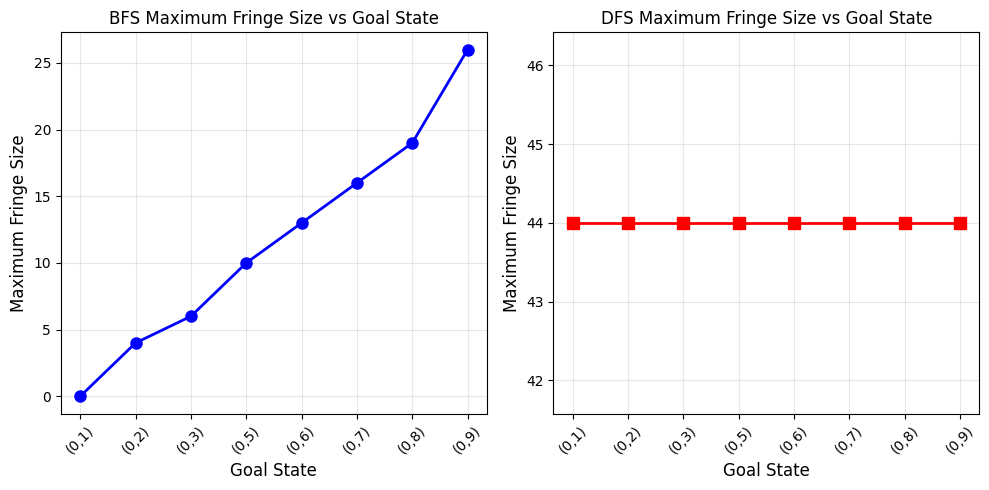


ANALYSIS: Fringe Size Growth

BFS Fringe Sizes: [0, 4, 6, 10, 13, 16, 19, 26]
DFS Fringe Sizes: [44, 44, 44, 44, 44, 44, 44, 44]

BFS Growth Pattern: Generally increases gradually with depth
  - BFS explores level by level, so fringe holds frontier nodes at current level
  - Fringe size ≈ branching factor ^ depth
  - Range: 0 to 26

DFS Growth Pattern: Highly variable, often much larger than BFS
  - DFS goes deep before backtracking, accumulating fringe nodes
  - Fringe can spike due to deep exploration paths
  - Range: 44 to 44

Returned result: ([0, 4, 6, 10, 13, 16, 19, 26], [44, 44, 44, 44, 44, 44, 44, 44])


In [2]:
# Run the multiple goals analysis
result = run_multiple_goals_analysis()
print(f"\nReturned result: {result}")